# Data-efficiency v2 — Physics Multires, \(n_{\mathrm{train}}=300\)

Follows **`PROTOCOL_v2.txt` / `PROTOCOL_v2.md`** (physics network, \(\lambda>0\)).

| Item | Value |
|------|-------|
| Protocol | **v2** |
| Data | Spectrally filtered C1 |
| Model | Multires + TRACE loss |
| \(n_{\mathrm{train}}\) | **300** |
| \(n_{\mathrm{val}}\) / \(n_{\mathrm{test}}\) | 200 / 512 (shared seeds) |
| Batch \(B\) | **64** |
| LR | **\(10^{-3}\)** fixed (same as plain / diagnostics) |
| `trace_scale` | **8** always |
| Train SNR | U[0, 30] dB |
| Val SNR | discrete **\{−10, 0, 30\}** dB |
| Budgets | `max_steps=6400`, `patience_steps=800` (same for every \(\lambda\) screen) |
| \(\lambda\) coarse | \(\{1.5,\ 3,\ 6,\ 12\}\) (+ optional 15; skip 0.75 this run) |
| \(\lambda\) fine | geometric bisection around coarse winner |
| Official model | **winning screen checkpoint** — **no** retrain-from-scratch |

Artifacts: `checkpoints/v2/n300_physics/`

After \(\lambda^\*\): evaluate that run on test (SNR sweep, example @ 10 dB). Plot per-\(\lambda\) train/val curves + overlays (as in `physics_multires_n2498_NB`).


In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from pathlib import Path
import json
import math
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

HERE = Path.cwd()
if (HERE / "setup_src_path.py").exists():
    sys.path.insert(0, str(HERE))
    import setup_src_path  # noqa: F401
    EXP = HERE
elif (HERE / "data efficiency experiment" / "setup_src_path.py").exists():
    EXP = HERE / "data efficiency experiment"
    sys.path.insert(0, str(EXP))
    import setup_src_path  # noqa: F401
else:
    raise RuntimeError("Run from src/ or from data efficiency experiment/")

import data_c_amb_loss_diagnostics as diag
from data_generation import filtered_c1_pulse_config
from dataset_utils import build_filtered_c1_frog_dataloaders
from evaluate_cnn import load_cnn_sweep
from frog_reconstruction_model import extract_pulse_prediction
from pulse_metrics import (
    best_l1_ambiguity,
    best_l1_ambiguity_field,
    best_similarity_error_ambiguity,
    prepare_frog_trace_for_plot,
    unpack_packed_field,
    unwrap_phases_for_overlay,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
OUT = EXP / "checkpoints" / "v2" / "n300_physics"
OUT.mkdir(parents=True, exist_ok=True)
PLAIN_OUT = EXP / "checkpoints" / "v2" / "n300_plain"

PROTOCOL = "v2"
N_TRAIN = 300
N_VAL = 200
N_TEST = 512
BATCH_SIZE = 64
SEED = 0
LR = 1e-3
TRACE_SCALE = 8.0
EARLY_STOP_MODE = "steps"
TRAIN_SNR = (0.0, 30.0)
VAL_SNR_RANGE = (-10.0, 30.0)  # unused when values set
VAL_SNR_VALUES = [-10.0, 0.0, 30.0]
SNR_SWEEP_DB = np.arange(-10.0, 31.0, 5.0)
SNAPSHOT_EVERY = 2
SNAPSHOT_SNR_DB = 10.0
SNAPSHOT_VAL_INDEX = 0
SNAPSHOT_NOISE_SEED = 12345

STEPS_PER_EPOCH = math.ceil(N_TRAIN / BATCH_SIZE)  # K
MAX_STEPS = 6400
PATIENCE_STEPS = 800
MAX_EPOCHS = max(1, math.ceil(MAX_STEPS / STEPS_PER_EPOCH))

# PROTOCOL v2 §5.2
LAMBDA_COARSE = [1.5, 3.0, 6.0, 12.0]  # skip 0.75 this run
INCLUDE_LAMBDA_15 = True  # optional extra coarse point
if INCLUDE_LAMBDA_15 and 15.0 not in LAMBDA_COARSE:
    LAMBDA_COARSE = sorted(LAMBDA_COARSE + [15.0])

FORCE_RETRAIN = False
FORCE_TEST_SWEEP = False

print("device:", DEVICE)
print("protocol:", PROTOCOL)
print("EXP:", EXP.resolve())
print("OUT:", OUT.resolve())
print("pulse cfg:", filtered_c1_pulse_config(n=64))
print(
    f"n_train={N_TRAIN}  B={BATCH_SIZE}  K={STEPS_PER_EPOCH}  "
    f"LR={LR:g}  trace_scale={TRACE_SCALE:g}  "
    f"max_steps={MAX_STEPS}  patience_steps={PATIENCE_STEPS}  max_epochs={MAX_EPOCHS}"
)
print("lambda coarse:", LAMBDA_COARSE)
print("train SNR: U[0,30]  |  val SNR values:", VAL_SNR_VALUES)
print(f"FORCE_RETRAIN={FORCE_RETRAIN}  FORCE_TEST_SWEEP={FORCE_TEST_SWEEP}")
if PLAIN_OUT.exists():
    print("plain v2 artifacts folder exists:", PLAIN_OUT)


device: cuda
protocol: v2
EXP: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment
OUT: D:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n300_physics
pulse cfg: FilteredC1PulseConfig(n=64, t_total_fs=70.0, n_spikes=500, central_energy_ev=10000.0, coherence_time_fs=1.0, t_center_std_fs=5.73, delta_energy_ev_range=0.00065, fwhm_ev=0.45, amplitude_min=0.75, amplitude_max=1.0, use_delta_omega=True)
n_train=300  B=64  K=5  LR=0.001  trace_scale=8  max_steps=6400  patience_steps=800  max_epochs=1280
lambda coarse: [1.5, 3.0, 6.0, 12.0, 15.0]
train SNR: U[0,30]  |  val SNR values: [-10.0, 0.0, 30.0]
FORCE_RETRAIN=False  FORCE_TEST_SWEEP=False
plain v2 artifacts folder exists: d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n300_plain


## Helpers


In [2]:
def lam_tag(lam: float) -> str:
    s = f"{float(lam):g}".replace(".", "p").replace("-", "m")
    return f"n{N_TRAIN}_phys_lam{s}_v2"


def load_meta(tag: str) -> dict:
    return json.loads((OUT / f"{tag}_meta.json").read_text(encoding="utf-8"))


def train_physics(tag: str, *, lam: float, role: str):
    hist_path = OUT / f"{tag}_history.npz"
    if hist_path.exists() and not FORCE_RETRAIN:
        print(f"skip {role}; using", hist_path)
        return None
    print(
        f"=== {role}: {tag}  lam={lam:g}  lr={LR:g}  "
        f"early_stop={EARLY_STOP_MODE}(patience_steps={PATIENCE_STEPS})  "
        f"max_steps={MAX_STEPS}  snap_every={SNAPSHOT_EVERY} ==="
    )
    t0 = time.perf_counter()
    result = diag.train_data_c_amb_diagnostics(
        pulse_loss_mode="raw",
        lam=float(lam),
        n_train=N_TRAIN,
        n_val=N_VAL,
        n_test=N_TEST,
        batch_size=BATCH_SIZE,
        seed=SEED,
        max_epochs=int(MAX_EPOCHS),
        patience=int(PATIENCE_STEPS),
        lr=float(LR),
        train_snr_db_range=TRAIN_SNR,
        val_snr_db_range=VAL_SNR_RANGE,
        val_snr_db_values=VAL_SNR_VALUES,
        device=DEVICE,
        verbose=True,
        ambiguity_backend="legacy",
        trace_loss_ref="clean",
        loader_builder="filtered_c1",
        canonicalize_mode="t0",
        max_steps=int(MAX_STEPS),
        fixed_trace_scale=TRACE_SCALE,
        snapshot_every=int(SNAPSHOT_EVERY),
        snapshot_snr_db=SNAPSHOT_SNR_DB,
        snapshot_val_index=SNAPSHOT_VAL_INDEX,
        snapshot_noise_seed=SNAPSHOT_NOISE_SEED,
        early_stop_mode=EARLY_STOP_MODE,
    )
    result_save = {k: v for k, v in result.items() if k != "bundle"}
    result_save["role"] = role
    result_save["protocol"] = PROTOCOL
    diag.save_run_artifacts(result_save, OUT, tag)
    meta = load_meta(tag)
    meta["role"] = role
    meta["protocol"] = PROTOCOL
    meta["val_snr_policy"] = "discrete_{-10,0,30}"
    meta["wall_time_total_sec"] = float(time.perf_counter() - t0)
    (OUT / f"{tag}_meta.json").write_text(json.dumps(meta, indent=2), encoding="utf-8")
    print(json.dumps(meta, indent=2))
    return result


def screen_one_lam(lam: float, *, role: str) -> dict:
    tag = lam_tag(lam)
    train_physics(tag, lam=lam, role=role)
    hist = diag.load_history(OUT / f"{tag}_history.npz")
    meta = load_meta(tag)
    plot_pulse_curves(hist, f"λ screen λ={lam:g}")
    plot_trace_curves(hist, f"λ screen λ={lam:g}")
    plot_grad_norms(hist, f"λ screen λ={lam:g}", lam=lam)
    return {
        "lam": float(lam),
        "tag": tag,
        "role": role,
        "best_score": float(meta["best_score"]),
        "best_epoch": int(meta["best_epoch"]),
        "best_step": int(meta.get("best_step") or 0),
        "stopped_epoch": int(meta["stopped_epoch"]),
        "global_step": int(meta.get("global_step") or 0),
    }


def fine_candidates(lam_star: float, coarse_grid: list[float]) -> list[float]:
    g = sorted(float(x) for x in coarse_grid)
    ls = float(lam_star)
    if ls not in g:
        g = sorted(g + [ls])
    i = g.index(ls)
    out = []
    if i > 0:
        out.append(float(np.sqrt(g[i - 1] * ls)))
    if i + 1 < len(g):
        out.append(float(np.sqrt(ls * g[i + 1])))
    # drop near-duplicates of already screened
    keep = []
    for x in out:
        if any(abs(np.log(x) - np.log(c)) < 1e-6 for c in g):
            continue
        keep.append(x)
    return keep


def summarize_timings(hist, name):
    keys = [
        "timing_data_prep_sec",
        "timing_loss_data_fwd_sec",
        "timing_loss_reg_fwd_sec",
        "timing_total_backward_sec",
        "timing_optimizer_step_sec",
    ]
    print(f"=== {name}: mean±std over epochs (ms/batch) ===")
    for k in keys:
        if k not in hist:
            continue
        x = np.asarray(hist[k], dtype=float) * 1e3
        print(f"  {k.replace('timing_', ''):22s}  {x.mean():7.3f} ± {x.std():6.3f}")


def plot_pulse_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_pulse_l1_raw"], label="raw")
    axes[0].plot(hist["train_pulse_l1_amb"], label="best-amb")
    axes[0].set_title(f"{title_prefix}: train pulse L1")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_pulse_l1_raw"], label="raw")
    axes[1].plot(hist["val_pulse_l1_amb"], label="best-amb")
    axes[1].set_title(f"{title_prefix}: val pulse L1 (SNR∈{{-10,0,30}})")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_trace_curves(hist, title_prefix):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["train_trace_l1"])
    axes[0].set_title(f"{title_prefix}: train TRACE L1")
    axes[0].set_xlabel("epoch")
    axes[0].grid(True, alpha=0.3)
    axes[1].plot(hist["val_trace_l1"])
    axes[1].set_title(f"{title_prefix}: val TRACE L1 (SNR∈{{-10,0,30}})")
    axes[1].set_xlabel("epoch")
    axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


def plot_grad_norms(hist, title_prefix, lam=0.0):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(hist["grad_norm_data"], label=r"$||\nabla L_{\mathrm{data}}||$")
    ax.semilogy(hist["grad_norm_reg"], label=r"$||\nabla L_{\mathrm{reg}}||$")
    if "grad_norm_total" in hist and len(hist["grad_norm_total"]):
        ax.semilogy(
            hist["grad_norm_total"],
            label=r"$||\nabla(L_{\mathrm{data}}+\lambda L_{\mathrm{reg}})||$",
        )
    ax.set_xlabel("epoch")
    ax.set_ylabel("grad norm")
    ax.set_title(f"{title_prefix} (λ={lam:g})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)


## Coarse $\lambda$ screening + sanity curves


=== lam_coarse: n300_phys_lam1p5_v2  lam=1.5  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=8.2084  tr_amb=6.9944  va_raw=6.4317  va_amb=6.0756  tr_trace=70.97  va_trace=59.80  |g_data|=1.705e+01  |g_reg|=4.714e-01  |g_tot|=1.756e+01  t_prep=0.83ms  t_Ld=28.35ms  t_Lr=9.88ms  t_bwd=88.86ms  t_opt=10.03ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.1047  tr_amb=5.7394  va_raw=5.6743  va_amb=5.1259  tr_trace=59.66  va_trace=58.55  |g_data|=1.624e+01  |g_reg|=6.468e+00  |g_tot|=2.077e+01  t_prep=0.62ms  t_Ld=15.82ms  t_Lr=9.97ms  t_bwd=36.69ms  t_opt=4.70ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=5.7009  tr_amb=4.9784  va_raw=5.7700  va_amb=5.1999  tr_trace=62.40  va_trace=57.97  |g_data|=2.136e+01  |g_reg|=1.105e+01  |g_tot|=3.544e+01  t_prep=0.71ms  t_Ld=15.87ms  t_Lr=10.45ms  t_bwd=37.83ms  t_opt=4.75ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=6.1045  tr_amb=5.6448  va_raw=6.1134  va_amb=5.7231  

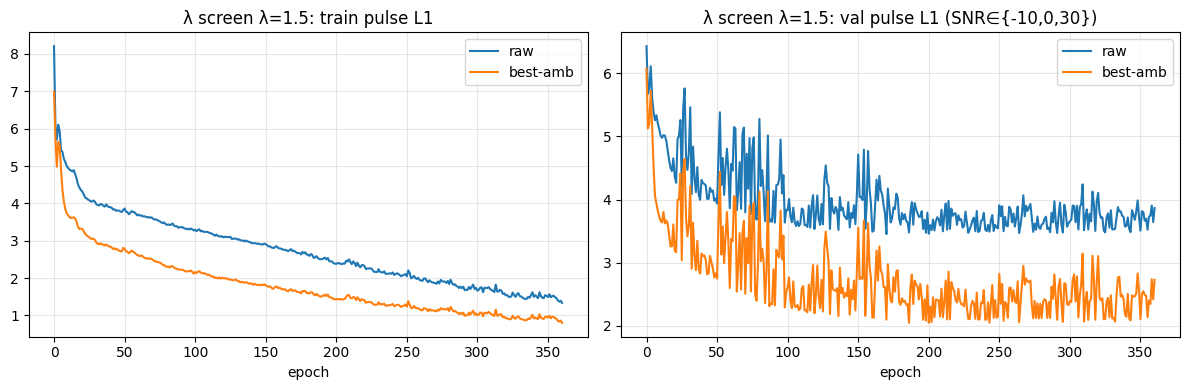

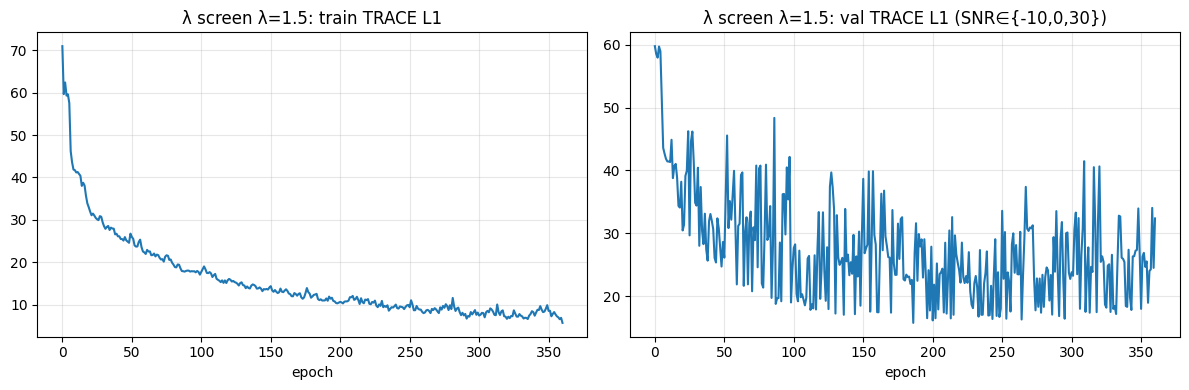

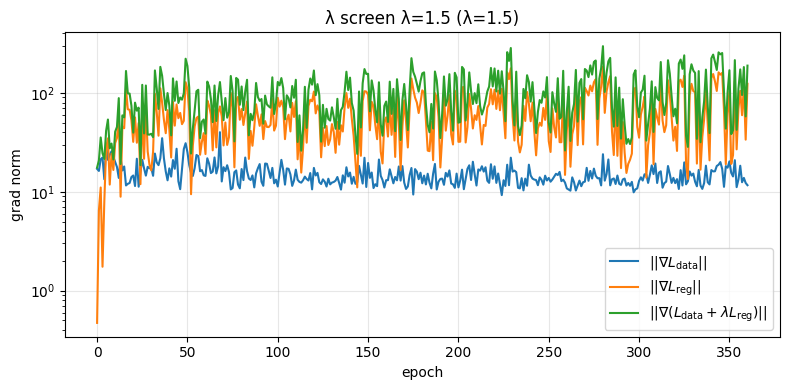

=== lam_coarse: n300_phys_lam3_v2  lam=3  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=8.0060  tr_amb=6.9961  va_raw=6.1316  va_amb=5.8363  tr_trace=67.72  va_trace=59.73  |g_data|=1.204e+01  |g_reg|=5.672e-01  |g_tot|=1.293e+01  t_prep=1.06ms  t_Ld=41.30ms  t_Lr=11.46ms  t_bwd=37.63ms  t_opt=5.21ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.0674  tr_amb=5.5633  va_raw=5.5003  va_amb=4.8261  tr_trace=59.43  va_trace=54.96  |g_data|=1.882e+01  |g_reg|=2.577e+01  |g_tot|=8.650e+01  t_prep=0.77ms  t_Ld=16.12ms  t_Lr=11.34ms  t_bwd=37.12ms  t_opt=5.04ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=6.0505  tr_amb=5.5125  va_raw=6.6809  va_amb=5.9917  tr_trace=58.39  va_trace=59.82  |g_data|=2.218e+01  |g_reg|=4.751e+00  |g_tot|=3.246e+01  t_prep=0.74ms  t_Ld=16.24ms  t_Lr=10.31ms  t_bwd=36.88ms  t_opt=4.99ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=6.3528  tr_amb=5.5428  va_raw=5.8153  va_amb=5.1643  tr_

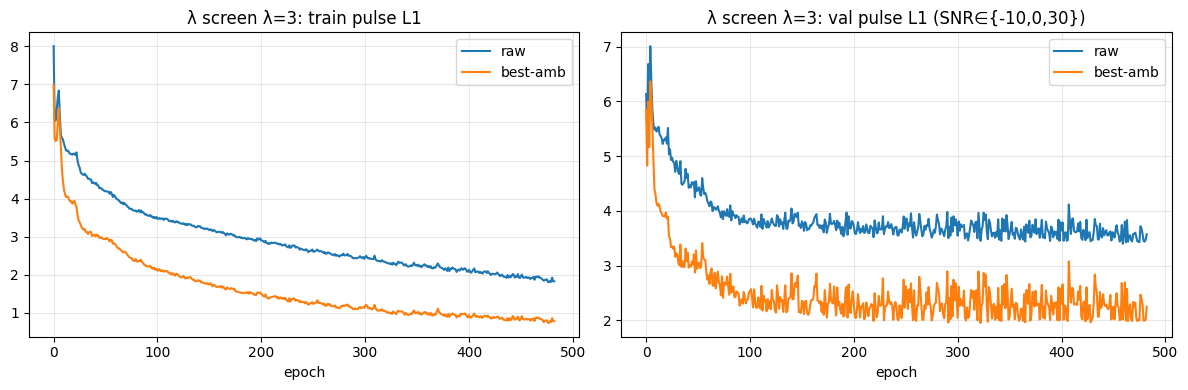

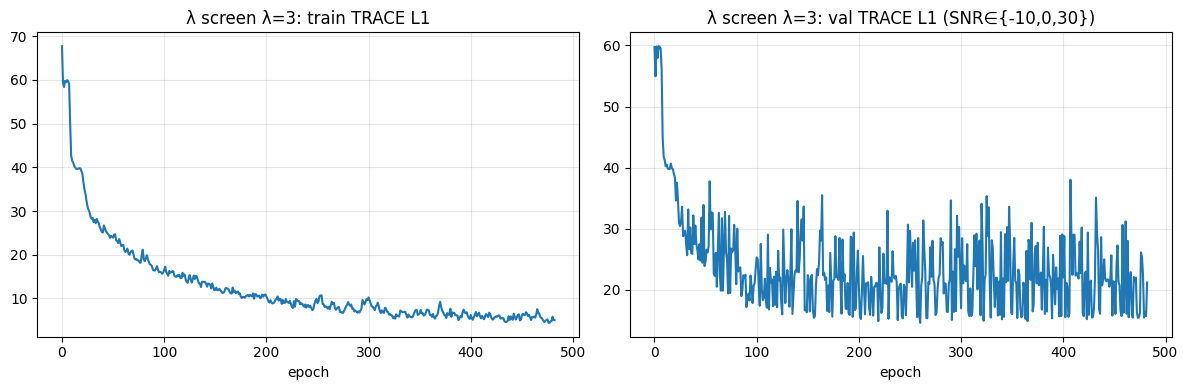

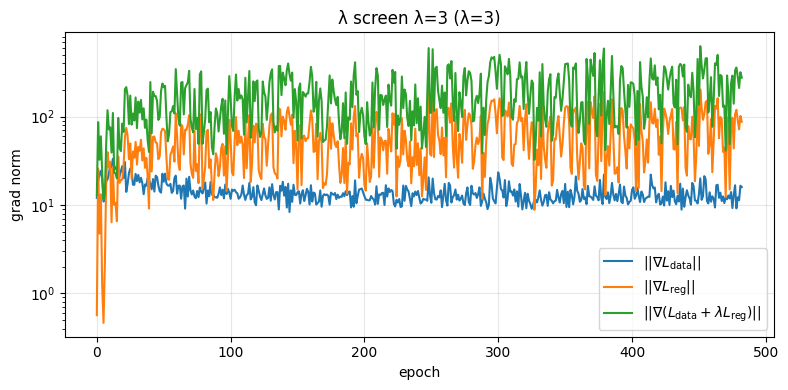

=== lam_coarse: n300_phys_lam6_v2  lam=6  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=7.7603  tr_amb=6.6883  va_raw=6.4076  va_amb=5.9823  tr_trace=63.70  va_trace=59.77  |g_data|=1.869e+01  |g_reg|=5.877e-01  |g_tot|=2.107e+01  t_prep=1.00ms  t_Ld=47.00ms  t_Lr=10.89ms  t_bwd=55.47ms  t_opt=5.17ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.0112  tr_amb=5.5139  va_raw=6.4730  va_amb=5.1604  tr_trace=59.00  va_trace=53.64  |g_data|=4.974e+01  |g_reg|=9.924e+01  |g_tot|=6.377e+02  t_prep=0.79ms  t_Ld=16.24ms  t_Lr=10.62ms  t_bwd=36.76ms  t_opt=5.19ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=6.0365  tr_amb=4.9300  va_raw=6.6584  va_amb=5.1910  tr_trace=52.32  va_trace=53.34  |g_data|=4.147e+01  |g_reg|=1.251e+02  |g_tot|=7.850e+02  t_prep=0.76ms  t_Ld=16.03ms  t_Lr=11.81ms  t_bwd=37.50ms  t_opt=5.07ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=5.8488  tr_amb=4.6464  va_raw=5.7851  va_amb=4.6966  tr_

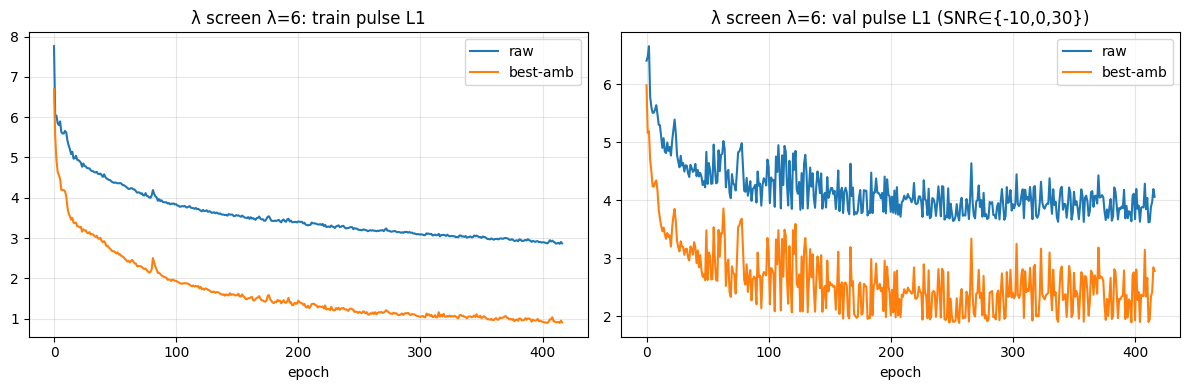

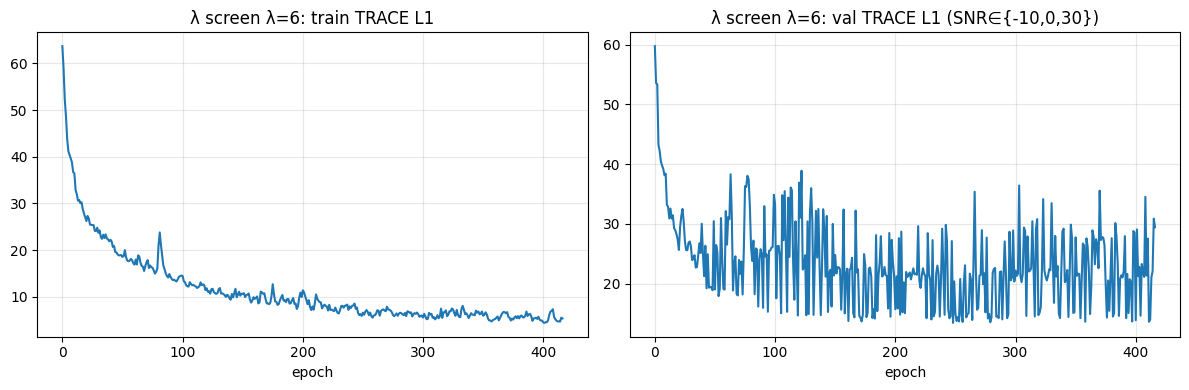

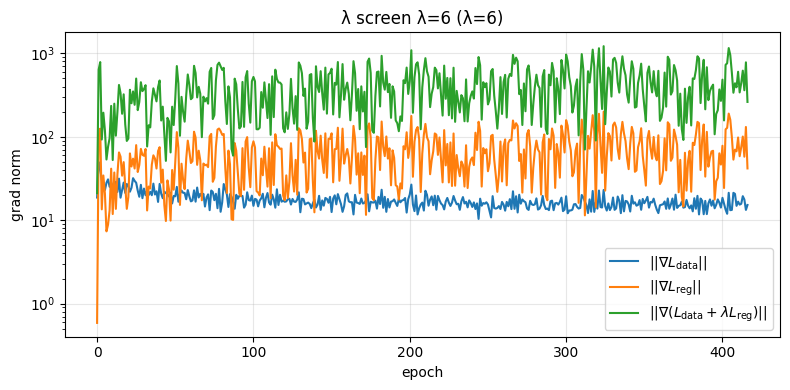

=== lam_coarse: n300_phys_lam12_v2  lam=12  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=7.9438  tr_amb=6.7483  va_raw=6.7636  va_amb=6.2786  tr_trace=64.07  va_trace=59.88  |g_data|=2.611e+01  |g_reg|=1.153e+00  |g_tot|=3.884e+01  t_prep=1.05ms  t_Ld=45.70ms  t_Lr=11.23ms  t_bwd=52.39ms  t_opt=4.84ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.2021  tr_amb=5.7738  va_raw=7.7994  va_amb=6.4780  tr_trace=59.46  va_trace=106.79  |g_data|=8.415e+01  |g_reg|=3.599e+02  |g_tot|=4.399e+03  t_prep=0.61ms  t_Ld=15.87ms  t_Lr=9.83ms  t_bwd=36.49ms  t_opt=4.82ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=6.7425  tr_amb=5.8630  va_raw=7.2971  va_amb=6.3236  tr_trace=61.52  va_trace=59.94  |g_data|=1.190e+01  |g_reg|=5.915e-01  |g_tot|=1.560e+01  t_prep=0.62ms  t_Ld=15.81ms  t_Lr=8.90ms  t_bwd=36.80ms  t_opt=4.79ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=7.2430  tr_amb=6.3429  va_raw=6.8837  va_amb=6.3011  tr

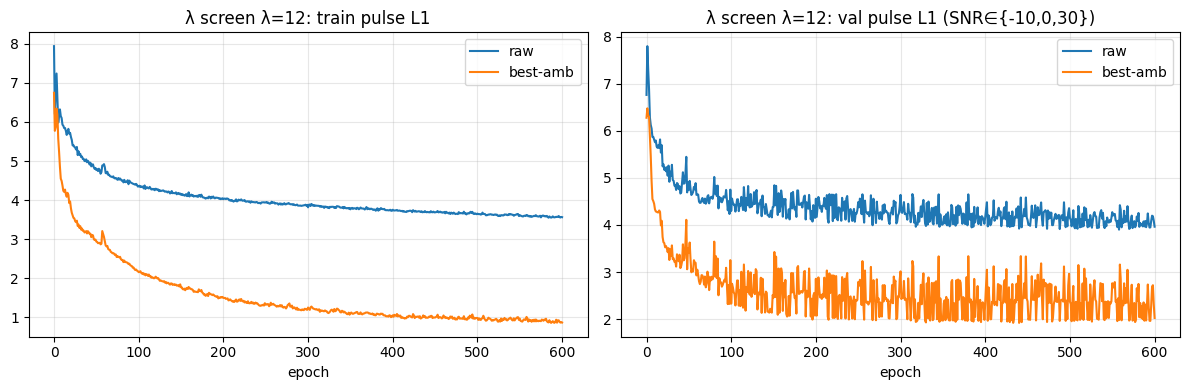

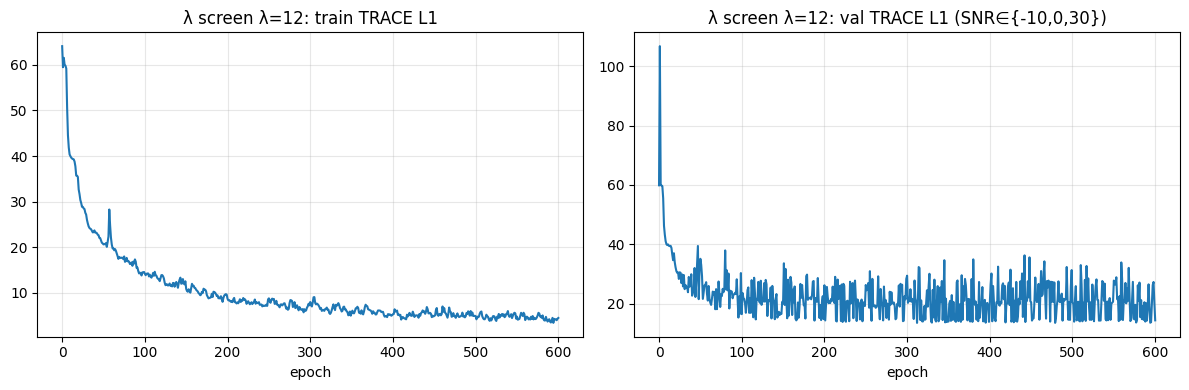

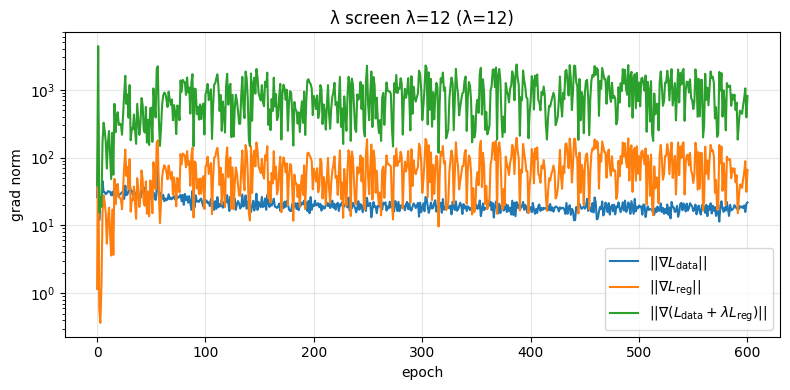

=== lam_coarse: n300_phys_lam15_v2  lam=15  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=7.6082  tr_amb=6.7698  va_raw=6.8171  va_amb=6.3190  tr_trace=62.75  va_trace=59.91  |g_data|=2.849e+01  |g_reg|=9.272e-01  |g_tot|=4.135e+01  t_prep=1.00ms  t_Ld=33.63ms  t_Lr=11.29ms  t_bwd=38.68ms  t_opt=5.30ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.2574  tr_amb=5.9730  va_raw=6.0795  va_amb=5.5017  tr_trace=59.78  va_trace=58.76  |g_data|=1.994e+01  |g_reg|=4.293e+00  |g_tot|=6.169e+01  t_prep=0.66ms  t_Ld=17.74ms  t_Lr=12.36ms  t_bwd=41.00ms  t_opt=5.28ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=7.0953  tr_amb=5.9868  va_raw=6.7579  va_amb=6.2394  tr_trace=108.36  va_trace=59.75  |g_data|=1.539e+01  |g_reg|=1.021e+00  |g_tot|=2.699e+01  t_prep=0.63ms  t_Ld=16.70ms  t_Lr=11.94ms  t_bwd=38.37ms  t_opt=5.28ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=7.0922  tr_amb=6.3581  va_raw=7.1823  va_amb=6.4352  

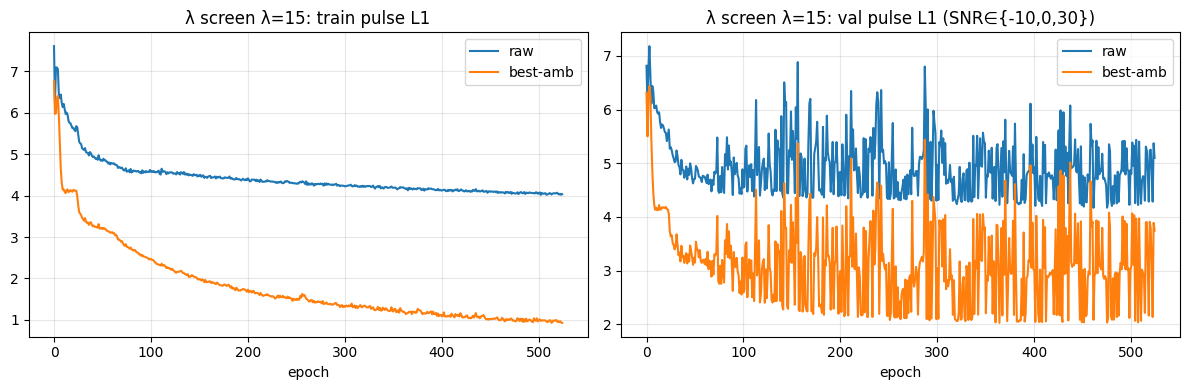

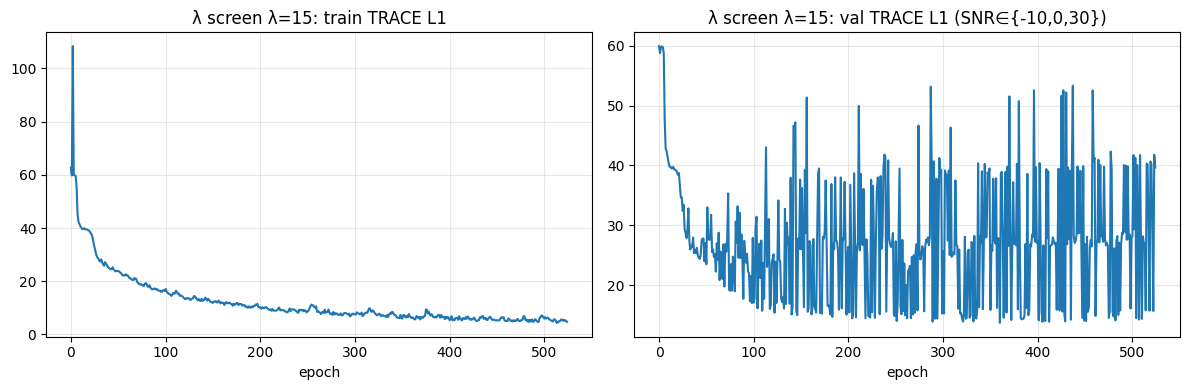

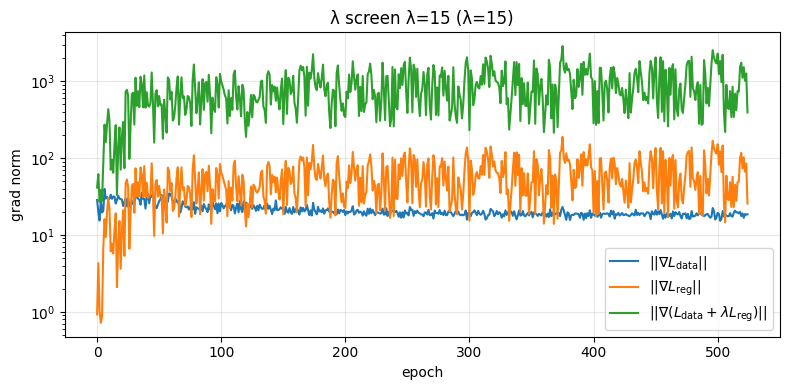

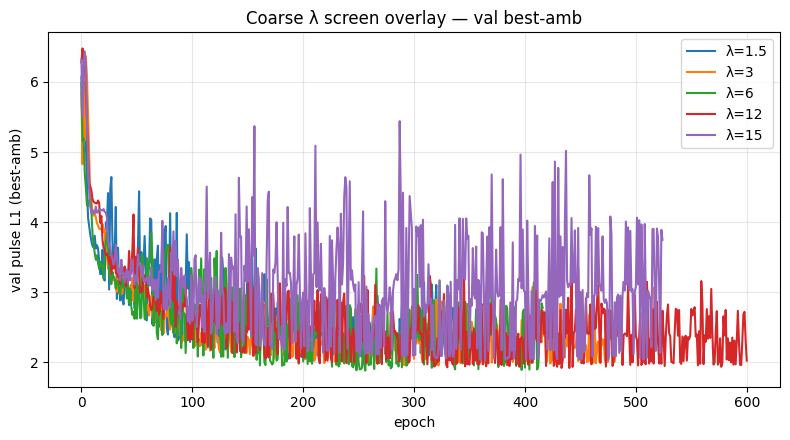

\n=== Coarse λ screening summary ===
  λ=1.5  best_score=2.045183  best_epoch=201  best_step=1005  stopped=361
  λ=3  best_score=1.954926  best_epoch=323  best_step=1615  stopped=483
  λ=6  best_score=1.881488  best_epoch=257  best_step=1285  stopped=417
  λ=12  best_score=1.919074  best_epoch=441  best_step=2205  stopped=601
  λ=15  best_score=2.026001  best_epoch=365  best_step=1825  stopped=525
\ncoarse λ* = 6


In [3]:
coarse_rows = []
for lam in LAMBDA_COARSE:
    coarse_rows.append(screen_one_lam(lam, role="lam_coarse"))

fig, ax = plt.subplots(figsize=(8, 4.5))
for r in coarse_rows:
    h = diag.load_history(OUT / f"{r['tag']}_history.npz")
    ax.plot(h["val_pulse_l1_amb"], label=f"λ={r['lam']:g}")
ax.set_xlabel("epoch")
ax.set_ylabel("val pulse L1 (best-amb)")
ax.set_title("Coarse λ screen overlay — val best-amb")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\\n=== Coarse λ screening summary ===")
for r in sorted(coarse_rows, key=lambda x: x["lam"]):
    print(
        f"  λ={r['lam']:g}  best_score={r['best_score']:.6f}  "
        f"best_epoch={r['best_epoch']}  best_step={r['best_step']}  "
        f"stopped={r['stopped_epoch']}"
    )
best_coarse = min(coarse_rows, key=lambda x: x["best_score"])
LAM_STAR = float(best_coarse["lam"])
print(f"\\ncoarse λ* = {LAM_STAR:g}")


## Fine $\lambda$ search (geometric bisection) + sanity curves


fine candidates: [4.242640687119285, 8.48528137423857]
=== lam_fine: n300_phys_lam4p24264_v2  lam=4.24264  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=7.7531  tr_amb=6.7807  va_raw=6.3098  va_amb=6.0019  tr_trace=64.96  va_trace=59.76  |g_data|=1.582e+01  |g_reg|=4.348e-01  |g_tot|=1.701e+01  t_prep=1.09ms  t_Ld=46.12ms  t_Lr=12.62ms  t_bwd=52.83ms  t_opt=5.30ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=5.9650  tr_amb=5.6422  va_raw=6.5513  va_amb=5.4485  tr_trace=59.35  va_trace=56.47  |g_data|=4.231e+01  |g_reg|=2.166e+01  |g_tot|=1.230e+02  t_prep=0.69ms  t_Ld=16.72ms  t_Lr=9.84ms  t_bwd=38.17ms  t_opt=4.92ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=5.8059  tr_amb=4.9643  va_raw=6.0783  va_amb=5.5280  tr_trace=56.31  va_trace=59.03  |g_data|=1.742e+01  |g_reg|=5.481e+00  |g_tot|=3.813e+01  t_prep=0.71ms  t_Ld=16.56ms  t_Lr=11.57ms  t_bwd=38.80ms  t_opt=5.12ms
[raw|legacy] epoch 004/1280  step=20 

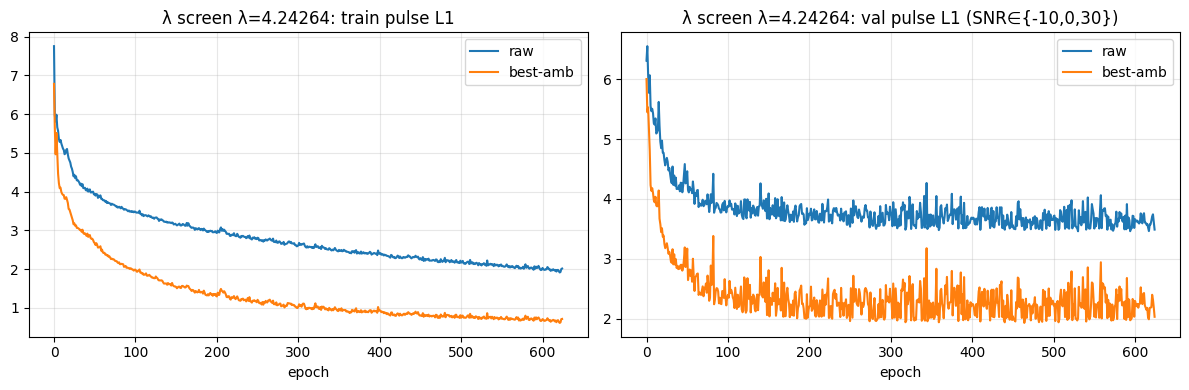

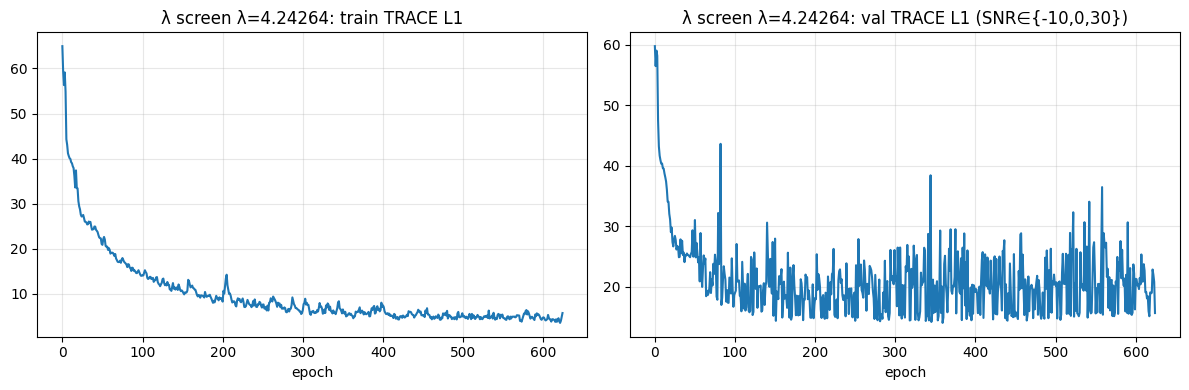

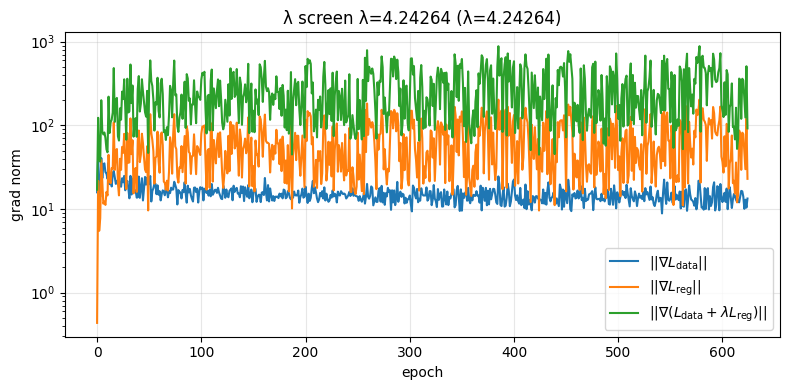

=== lam_fine: n300_phys_lam8p48528_v2  lam=8.48528  lr=0.001  early_stop=steps(patience_steps=800)  max_steps=6400  snap_every=2 ===
[raw|legacy] epoch 001/1280  step=5  tr_raw=7.5094  tr_amb=6.5371  va_raw=6.2413  va_amb=5.9473  tr_trace=61.63  va_trace=59.76  |g_data|=1.779e+01  |g_reg|=1.907e-01  |g_tot|=1.906e+01  t_prep=0.89ms  t_Ld=44.34ms  t_Lr=10.03ms  t_bwd=36.60ms  t_opt=4.90ms
[raw|legacy] epoch 002/1280  step=10  tr_raw=6.2354  tr_amb=5.9048  va_raw=6.2131  va_amb=5.3930  tr_trace=59.69  va_trace=56.26  |g_data|=2.969e+01  |g_reg|=1.344e+01  |g_tot|=1.060e+02  t_prep=0.56ms  t_Ld=15.89ms  t_Lr=9.61ms  t_bwd=35.94ms  t_opt=4.69ms
[raw|legacy] epoch 003/1280  step=15  tr_raw=6.3385  tr_amb=5.6149  va_raw=6.8858  va_amb=6.2827  tr_trace=68.14  va_trace=59.84  |g_data|=1.184e+01  |g_reg|=3.724e-01  |g_tot|=1.387e+01  t_prep=0.55ms  t_Ld=15.93ms  t_Lr=9.65ms  t_bwd=35.62ms  t_opt=4.69ms
[raw|legacy] epoch 004/1280  step=20  tr_raw=7.0830  tr_amb=6.3482  va_raw=7.0669  va_amb=6.3

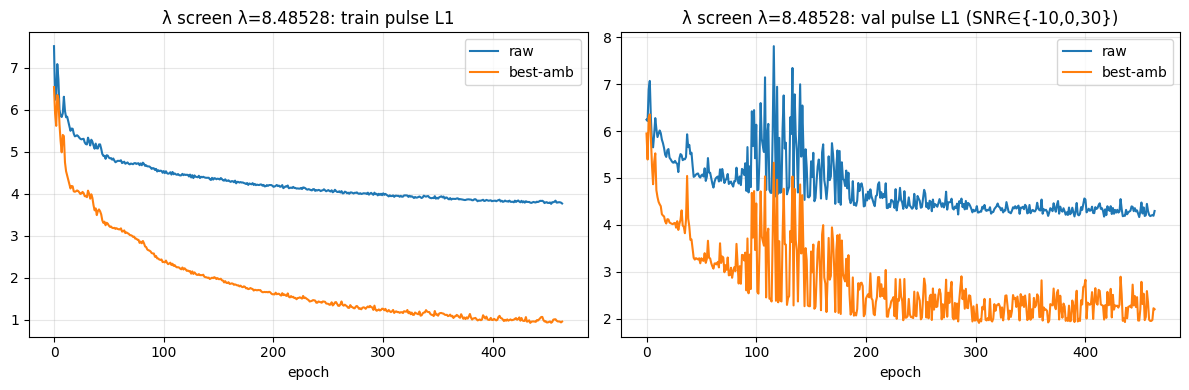

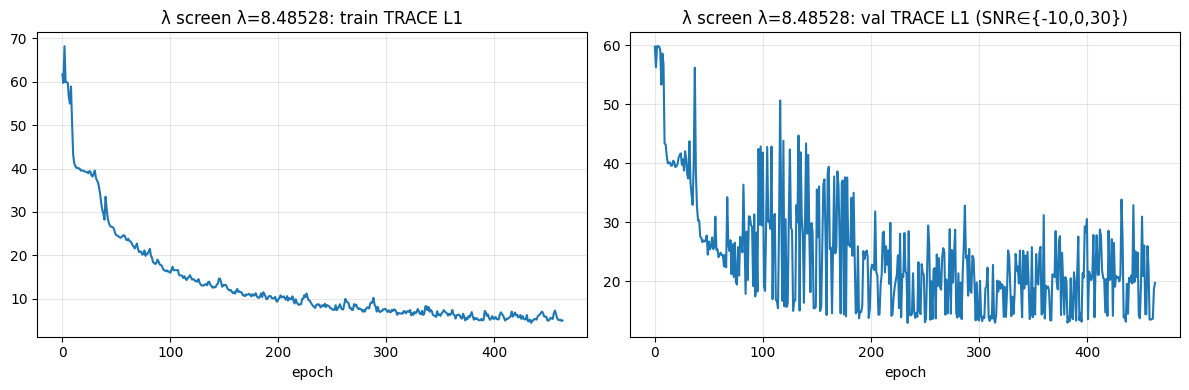

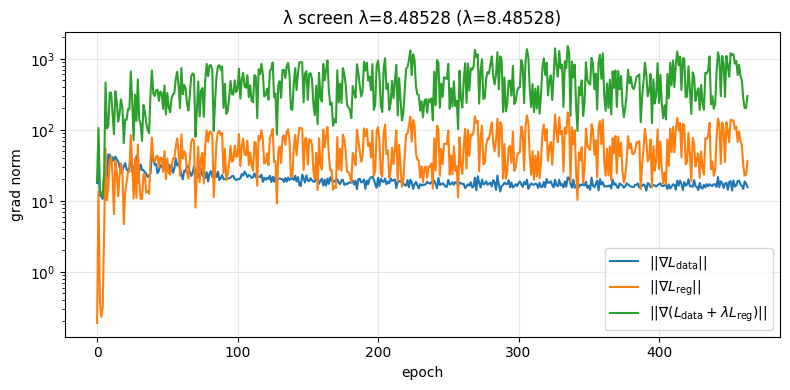

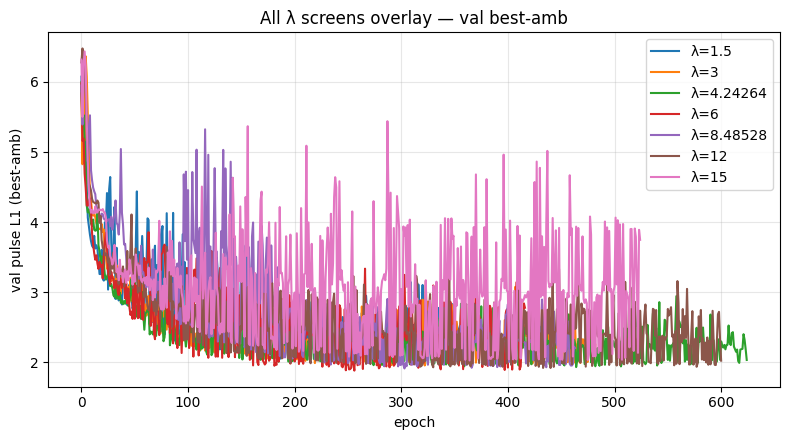

\n=== All λ screening summary ===
  λ=1.5  role=lam_coarse  best_score=2.045183  best_epoch=201  best_step=1005  stopped=361
  λ=3  role=lam_coarse  best_score=1.954926  best_epoch=323  best_step=1615  stopped=483
  λ=4.24264  role=lam_fine  best_score=1.931787  best_epoch=465  best_step=2325  stopped=625
  λ=6  role=lam_coarse  best_score=1.881488  best_epoch=257  best_step=1285  stopped=417
  λ=8.48528  role=lam_fine  best_score=1.912288  best_epoch=304  best_step=1520  stopped=464
  λ=12  role=lam_coarse  best_score=1.919074  best_epoch=441  best_step=2205  stopped=601
  λ=15  role=lam_coarse  best_score=2.026001  best_epoch=365  best_step=1825  stopped=525
\nλ* = 6  TAG_STAR = n300_phys_lam6_v2
wrote d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n300_physics\lambda_screen_summary.json


In [4]:
fine_lams = fine_candidates(LAM_STAR, LAMBDA_COARSE)
print("fine candidates:", fine_lams)
fine_rows = []
for lam in fine_lams:
    fine_rows.append(screen_one_lam(lam, role="lam_fine"))

all_rows = list(coarse_rows) + list(fine_rows)
best = min(all_rows, key=lambda x: x["best_score"])
LAM_STAR = float(best["lam"])
TAG_STAR = best["tag"]

fig, ax = plt.subplots(figsize=(8, 4.5))
for r in sorted(all_rows, key=lambda x: x["lam"]):
    h = diag.load_history(OUT / f"{r['tag']}_history.npz")
    ax.plot(h["val_pulse_l1_amb"], label=f"λ={r['lam']:g}")
ax.set_xlabel("epoch")
ax.set_ylabel("val pulse L1 (best-amb)")
ax.set_title("All λ screens overlay — val best-amb")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\\n=== All λ screening summary ===")
for r in sorted(all_rows, key=lambda x: x["lam"]):
    print(
        f"  λ={r['lam']:g}  role={r['role']}  best_score={r['best_score']:.6f}  "
        f"best_epoch={r['best_epoch']}  best_step={r['best_step']}  "
        f"stopped={r['stopped_epoch']}"
    )
print(f"\\nλ* = {LAM_STAR:g}  TAG_STAR = {TAG_STAR}")
(OUT / "lambda_screen_summary.json").write_text(
    json.dumps(
        {
            "protocol": PROTOCOL,
            "LR": LR,
            "TRACE_SCALE": TRACE_SCALE,
            "LAM_STAR": LAM_STAR,
            "TAG_STAR": TAG_STAR,
            "coarse_rows": coarse_rows,
            "fine_rows": fine_rows,
            "rows": all_rows,
        },
        indent=2,
    ),
    encoding="utf-8",
)
print("wrote", OUT / "lambda_screen_summary.json")


## Official physics model = \(\lambda^\*\) screen winner (no retrain)

Per PROTOCOL v2: evaluate the **winning screening checkpoint** on test. Load curves / snapshots from that tag.


{
  "best_epoch": 257,
  "best_score": 1.8814876091480255,
  "stopped_epoch": 417,
  "lam": 6.0,
  "trace_scale": 8.0,
  "pulse_loss_mode": "raw",
  "ambiguity_backend": "legacy",
  "trace_loss_ref": "clean",
  "device": "cuda",
  "train_snr_db_range": [
    0.0,
    30.0
  ],
  "train_snr_db_values": null,
  "val_snr_db_range": [
    -10.0,
    30.0
  ],
  "val_snr_db_values": [
    -10.0,
    0.0,
    30.0
  ],
  "n_train": 300,
  "n_val": 200,
  "seed": 0,
  "loader_builder": "filtered_c1",
  "canonicalize_mode": "t0",
  "lr": 0.001,
  "batch_size": 64,
  "max_steps": 6400,
  "global_step": 2085,
  "best_step": 1285,
  "early_stop_mode": "steps",
  "early_stop_frac": 0.9,
  "patience": 800,
  "wall_time_data_sec": 8.686559000052512,
  "wall_time_train_sec": 832.8868664999027,
  "role": "lam_coarse",
  "protocol": "v2",
  "val_snr_policy": "discrete_{-10,0,30}",
  "wall_time_total_sec": 841.7300076000392
}


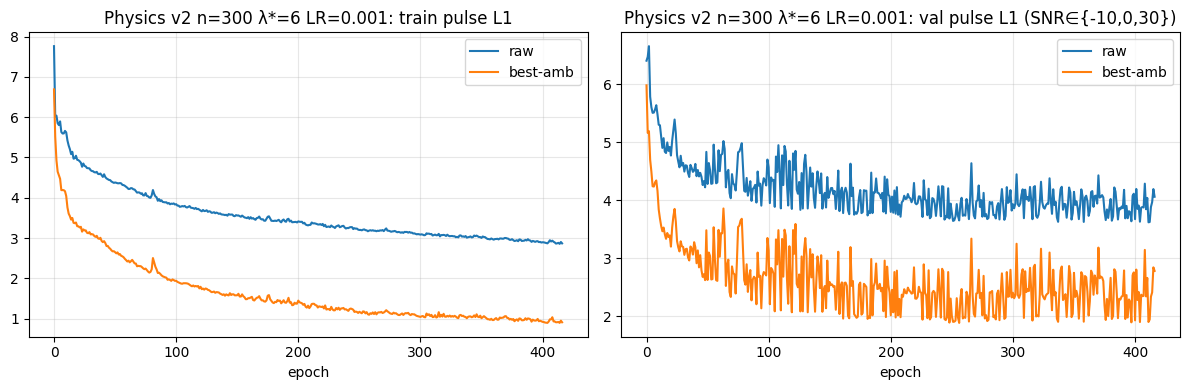

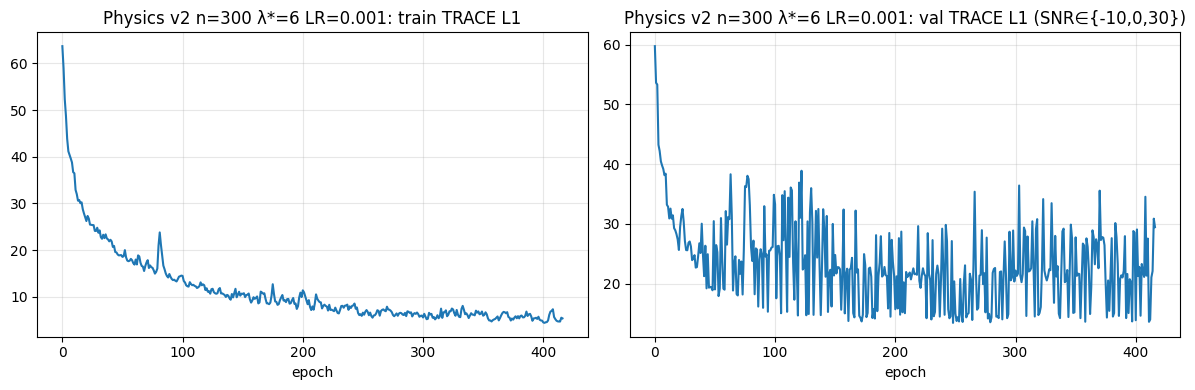

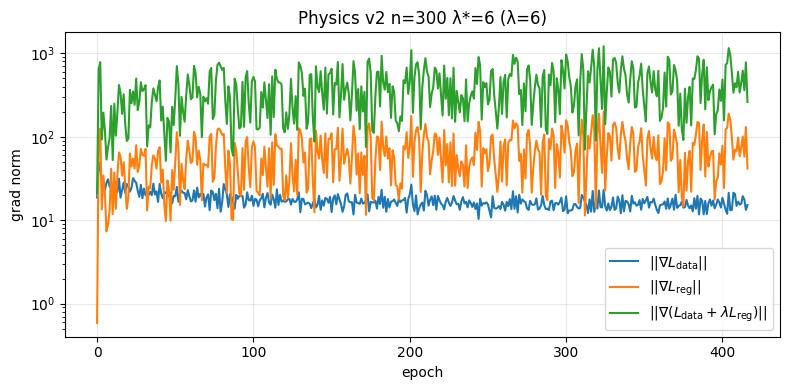

=== Physics v2 n=300 λ*=6: mean±std over epochs (ms/batch) ===
  data_prep_sec             0.699 ±  0.075
  loss_data_fwd_sec        16.102 ±  1.516
  loss_reg_fwd_sec         10.400 ±  0.694
  total_backward_sec       37.331 ±  0.988
  optimizer_step_sec        5.006 ±  0.101
wall_time_data_sec=8.686559000052512  wall_time_train_sec=832.8868664999027  best_step=1285  global_step=2085


In [5]:
hist = diag.load_history(OUT / f"{TAG_STAR}_history.npz")
meta = load_meta(TAG_STAR)
print(json.dumps(meta, indent=2))
plot_pulse_curves(hist, f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g} LR={LR:g}")
plot_trace_curves(hist, f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g} LR={LR:g}")
plot_grad_norms(hist, f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g}", lam=LAM_STAR)
summarize_timings(hist, f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g}")
print(
    f"wall_time_data_sec={meta.get('wall_time_data_sec')}  "
    f"wall_time_train_sec={meta.get('wall_time_train_sec')}  "
    f"best_step={meta.get('best_step')}  global_step={meta.get('global_step')}"
)


## Snapshot evolution (winner @ SNR=10 dB)


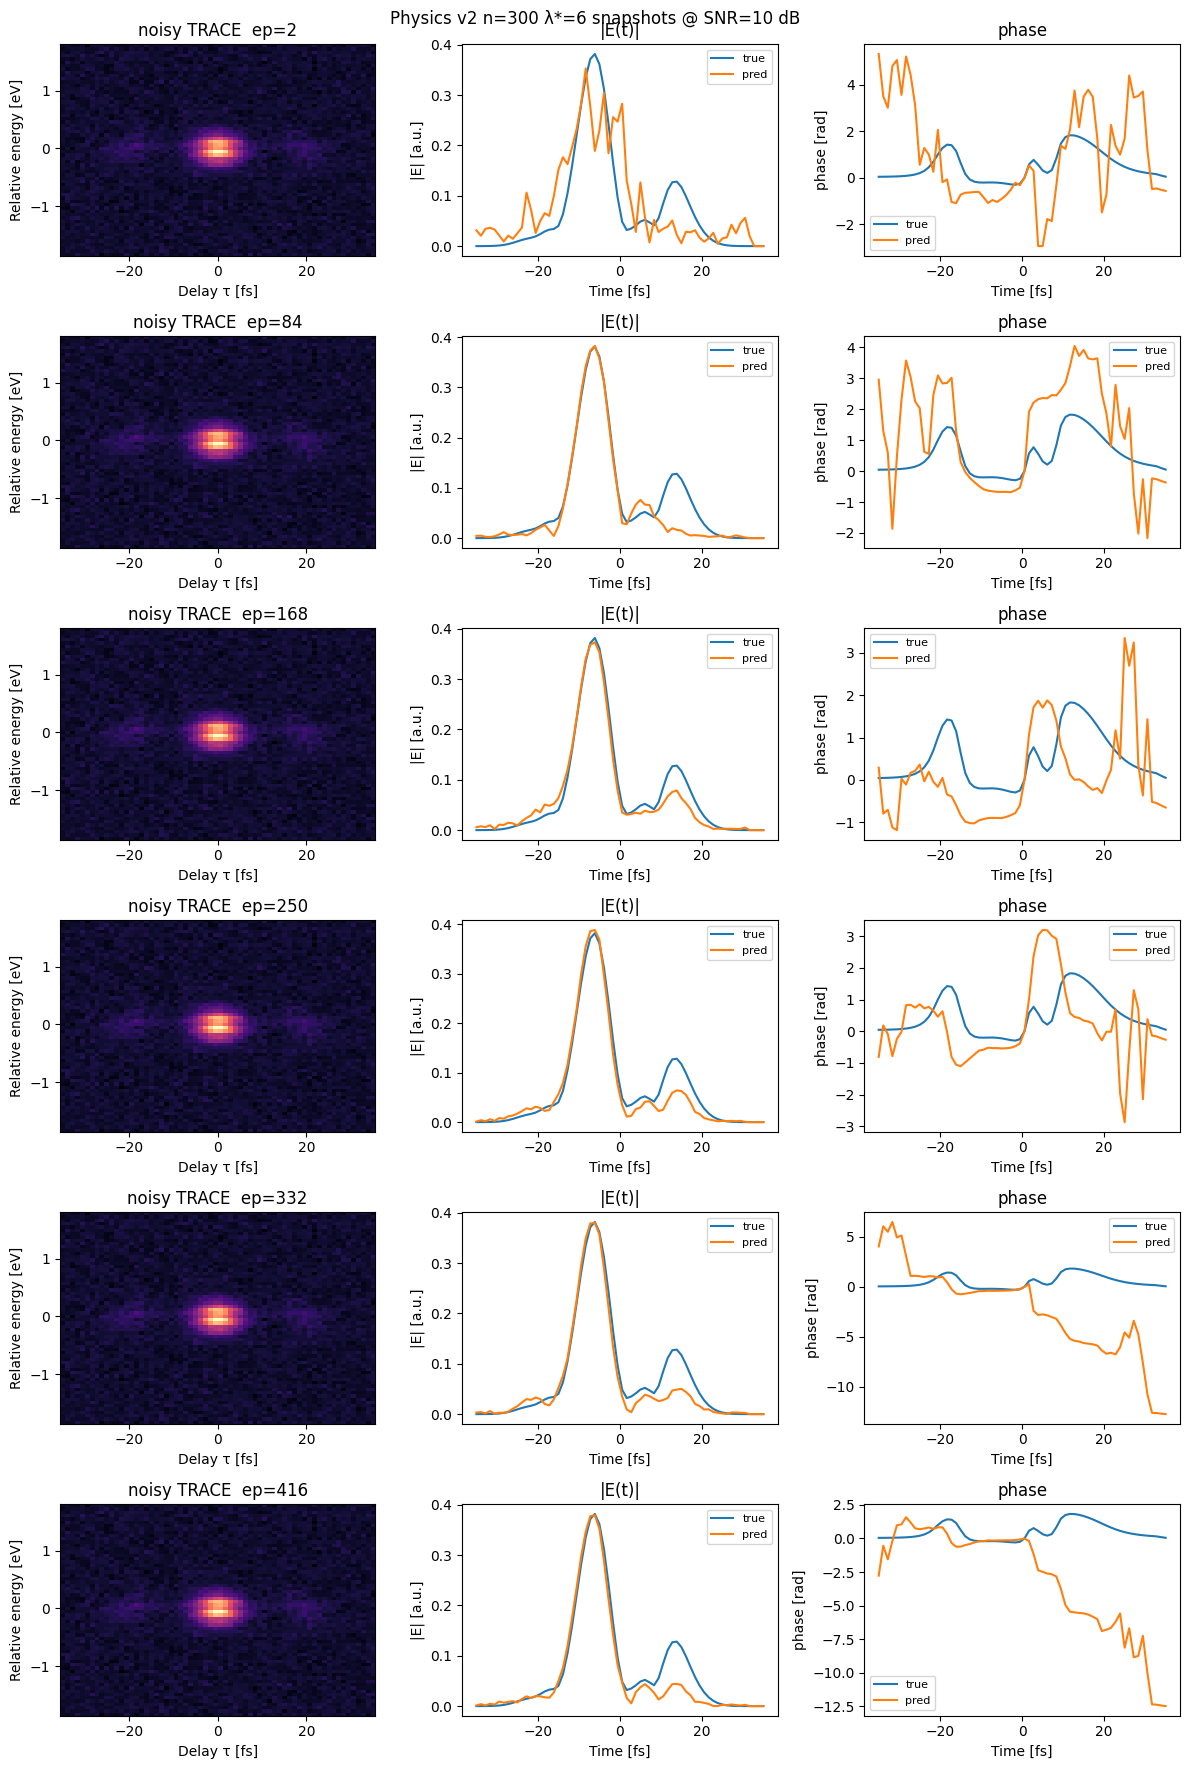

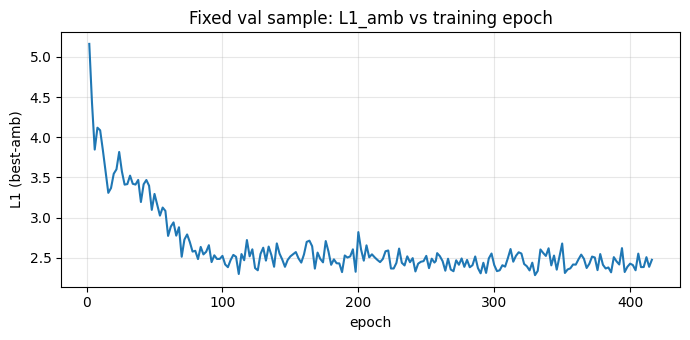

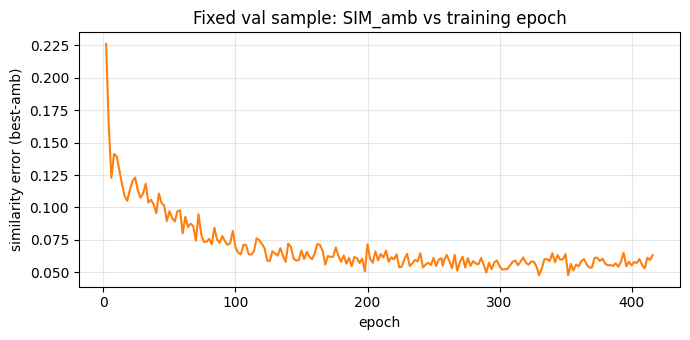

In [6]:
snap_path = OUT / f"{TAG_STAR}_snapshots.npz"
assert snap_path.exists(), snap_path
snap = np.load(snap_path)
epochs = snap["epoch"]
E_pred_all = snap["E_pred"]
if E_pred_all.ndim == 3:
    E_pred_all = E_pred_all[:, 0, :]
E_true = snap["E_true"]
if E_true.ndim == 3:
    E_true = E_true[0]
elif E_true.ndim == 2 and E_true.shape[0] == 1:
    E_true = E_true[0]
I_noisy = snap["I_noisy"]
if I_noisy.ndim == 4:
    I_noisy = I_noisy[0, 0]
elif I_noisy.ndim == 3:
    I_noisy = I_noisy[0]

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)
e_true = unpack_packed_field(E_true)
I_show, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy, num_points=pulse_cfg.n, dt=dt
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

n_show = min(6, len(epochs))
show_idx = np.unique(np.linspace(0, len(epochs) - 1, n_show, dtype=int)).tolist()
fig, axes = plt.subplots(len(show_idx), 3, figsize=(12, 3.0 * len(show_idx)))
if len(show_idx) == 1:
    axes = np.array([axes])
for row, si in enumerate(show_idx):
    e_pred = unpack_packed_field(E_pred_all[si])
    e_al = best_l1_ambiguity_field(e_pred, e_true)
    amp_p, amp_t = np.abs(e_al), np.abs(e_true)
    ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
    axes[row, 0].imshow(
        I_show, aspect="auto", origin="lower", extent=extent, cmap="magma"
    )
    axes[row, 0].set_title(f"noisy TRACE  ep={int(epochs[si])}")
    axes[row, 0].set_xlabel("Delay τ [fs]")
    axes[row, 0].set_ylabel("Relative energy [eV]")
    axes[row, 1].plot(t_axis, amp_t, label="true")
    axes[row, 1].plot(t_axis, amp_p, label="pred")
    axes[row, 1].set_title("|E(t)|")
    axes[row, 1].set_xlabel("Time [fs]")
    axes[row, 1].set_ylabel("|E| [a.u.]")
    axes[row, 1].legend(fontsize=8)
    axes[row, 2].plot(t_axis, ph_t, label="true")
    axes[row, 2].plot(t_axis, ph_p, label="pred")
    axes[row, 2].set_title("phase")
    axes[row, 2].set_xlabel("Time [fs]")
    axes[row, 2].set_ylabel("phase [rad]")
    axes[row, 2].legend(fontsize=8)
plt.suptitle(
    f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g} snapshots @ SNR={SNAPSHOT_SNR_DB:g} dB"
)
plt.tight_layout()
plt.show()

l1s, sims = [], []
for i in range(len(epochs)):
    e_pred = unpack_packed_field(E_pred_all[i])
    l1s.append(best_l1_ambiguity(e_pred, e_true))
    sims.append(best_similarity_error_ambiguity(e_pred, e_true))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, l1s, color="C0")
ax.set_xlabel("epoch")
ax.set_ylabel("L1 (best-amb)")
ax.set_title("Fixed val sample: L1_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(epochs, sims, color="C1")
ax.set_xlabel("epoch")
ax.set_ylabel("similarity error (best-amb)")
ax.set_title("Fixed val sample: SIM_amb vs training epoch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Held-out test SNR sweep (λ* winner)


Running test SNR sweep...
CNN sweep @ -10.0 dB …
CNN sweep @ -5.0 dB …
CNN sweep @ 0.0 dB …
CNN sweep @ 5.0 dB …
CNN sweep @ 10.0 dB …
CNN sweep @ 15.0 dB …
CNN sweep @ 20.0 dB …
CNN sweep @ 25.0 dB …
CNN sweep @ 30.0 dB …


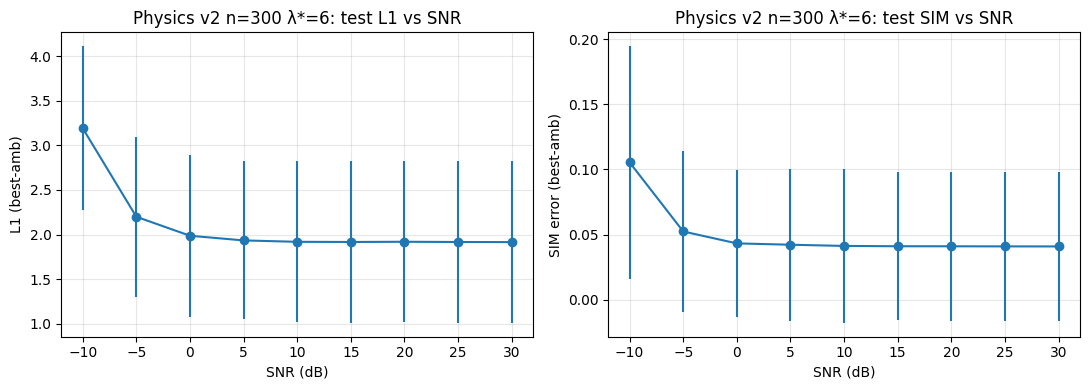

  SNR= -10.0  L1_amb=3.1910  SIM_amb=0.1054
  SNR=  -5.0  L1_amb=2.1990  SIM_amb=0.0525
  SNR=   0.0  L1_amb=1.9865  SIM_amb=0.0433
  SNR=   5.0  L1_amb=1.9341  SIM_amb=0.0423
  SNR=  10.0  L1_amb=1.9184  SIM_amb=0.0414
  SNR=  15.0  L1_amb=1.9167  SIM_amb=0.0411
  SNR=  20.0  L1_amb=1.9189  SIM_amb=0.0411
  SNR=  25.0  L1_amb=1.9164  SIM_amb=0.0410
  SNR=  30.0  L1_amb=1.9152  SIM_amb=0.0410


In [7]:
bundle = build_filtered_c1_frog_dataloaders(
    n_train=max(N_TRAIN, 64),
    n_val=N_VAL,
    n_test=N_TEST,
    batch_size=BATCH_SIZE,
    seed=SEED,
    device=DEVICE,
    grid=filtered_c1_pulse_config(n=64),
    canonicalize_mode="t0",
)
test_loader = bundle.test_loader

sweep_path = OUT / f"{TAG_STAR}_test_snr_sweep.npz"
if FORCE_TEST_SWEEP or not sweep_path.exists():
    print("Running test SNR sweep...")
    diag.run_and_save_test_snr_sweep(
        OUT / f"{TAG_STAR}_model.pt",
        sweep_path,
        test_loader=test_loader,
        snr_sweep_db=SNR_SWEEP_DB,
        device=DEVICE,
        experiment_name=f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g}",
    )
else:
    print("skip sweep; using", sweep_path)

sweep = load_cnn_sweep(sweep_path)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].errorbar(
    sweep.snr_sweep_db, sweep.cnn_l1_amb_m, yerr=sweep.cnn_l1_amb_s, marker="o"
)
axes[0].set_xlabel("SNR (dB)")
axes[0].set_ylabel("L1 (best-amb)")
axes[0].set_title(f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g}: test L1 vs SNR")
axes[0].grid(True, alpha=0.3)
axes[1].errorbar(
    sweep.snr_sweep_db, sweep.cnn_sim_amb_m, yerr=sweep.cnn_sim_amb_s, marker="o"
)
axes[1].set_xlabel("SNR (dB)")
axes[1].set_ylabel("SIM error (best-amb)")
axes[1].set_title(f"Physics v2 n={N_TRAIN} λ*={LAM_STAR:g}: test SIM vs SNR")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
for snr, l1, sim in zip(sweep.snr_sweep_db, sweep.cnn_l1_amb_m, sweep.cnn_sim_amb_m):
    print(f"  SNR={snr:6.1f}  L1_amb={l1:.4f}  SIM_amb={sim:.4f}")


## Test example @ SNR = 10 dB


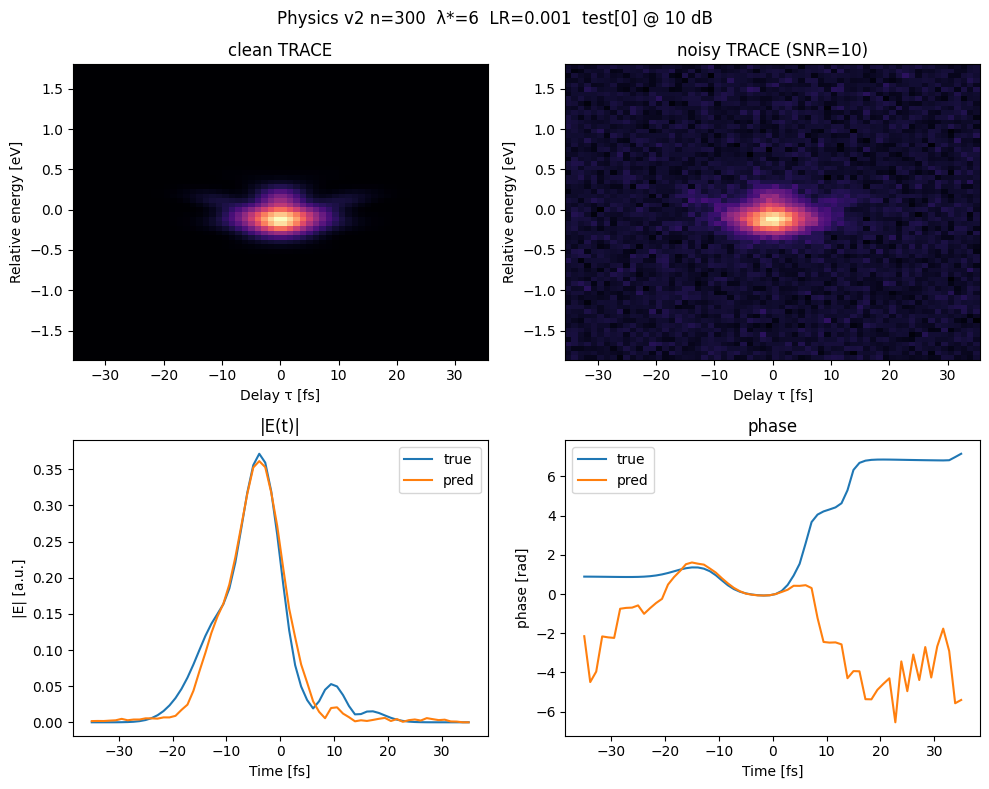

L1_amb: 1.2470133304595947
SIM_amb: 0.01453711268026825


In [8]:
model = diag.load_trained_multires(OUT / f"{TAG_STAR}_model.pt", device=DEVICE)
model.eval()

pulse_cfg = filtered_c1_pulse_config(n=64)
dt = float(pulse_cfg.dt)
t_axis = np.linspace(-pulse_cfg.t_total_fs / 2.0, pulse_cfg.t_total_fs / 2.0, pulse_cfg.n)

I_clean, E_true = test_loader.dataset[0]
I_clean_b = I_clean.unsqueeze(0).to(DEVICE)
E_np = E_true.detach().cpu().numpy()
g = torch.Generator()
g.manual_seed(999)
noise = torch.randn(I_clean_b.shape, generator=g, dtype=I_clean_b.dtype)
pwr = I_clean_b.pow(2).mean().clamp_min(1e-12)
sigma = torch.sqrt(pwr / (10.0 ** (10.0 / 10.0)))
I_noisy = I_clean_b + sigma * noise.to(DEVICE)

with torch.no_grad():
    E_pred = extract_pulse_prediction(model(I_noisy.unsqueeze(1))).squeeze(0).cpu().numpy()
e_true = unpack_packed_field(E_np)
e_pred = unpack_packed_field(E_pred)
e_al = best_l1_ambiguity_field(e_pred, e_true)
amp_p, amp_t = np.abs(e_al), np.abs(e_true)
ph_t, ph_p = unwrap_phases_for_overlay(e_al, e_true)
I_n, tau_axis, omega_plot = prepare_frog_trace_for_plot(
    I_noisy.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
I_c, _, _ = prepare_frog_trace_for_plot(
    I_clean_b.squeeze(0).cpu().numpy(),
    num_points=pulse_cfg.n,
    dt=dt,
)
energy_ev = omega_plot * 4.135667696 / (2.0 * np.pi)
extent = [tau_axis[0], tau_axis[-1], energy_ev[0], energy_ev[-1]]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes[0, 0].imshow(I_c, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 0].set_title("clean TRACE")
axes[0, 0].set_xlabel("Delay τ [fs]")
axes[0, 0].set_ylabel("Relative energy [eV]")
axes[0, 1].imshow(I_n, aspect="auto", origin="lower", extent=extent, cmap="magma")
axes[0, 1].set_title("noisy TRACE (SNR=10)")
axes[0, 1].set_xlabel("Delay τ [fs]")
axes[0, 1].set_ylabel("Relative energy [eV]")
axes[1, 0].plot(t_axis, amp_t, label="true")
axes[1, 0].plot(t_axis, amp_p, label="pred")
axes[1, 0].set_title("|E(t)|")
axes[1, 0].set_xlabel("Time [fs]")
axes[1, 0].set_ylabel("|E| [a.u.]")
axes[1, 0].legend()
axes[1, 1].plot(t_axis, ph_t, label="true")
axes[1, 1].plot(t_axis, ph_p, label="pred")
axes[1, 1].set_title("phase")
axes[1, 1].set_xlabel("Time [fs]")
axes[1, 1].set_ylabel("phase [rad]")
axes[1, 1].legend()
plt.suptitle(f"Physics v2 n={N_TRAIN}  λ*={LAM_STAR:g}  LR={LR:g}  test[0] @ 10 dB")
plt.tight_layout()
plt.show()

print("L1_amb:", best_l1_ambiguity(e_pred, e_true))
print("SIM_amb:", best_similarity_error_ambiguity(e_pred, e_true))


## Campaign summary row


In [9]:
summary = {
    "protocol": PROTOCOL,
    "n_train": N_TRAIN,
    "model": "physics",
    "lambda": LAM_STAR,
    "LR": LR,
    "trace_scale": TRACE_SCALE,
    "batch_size": BATCH_SIZE,
    "max_steps": MAX_STEPS,
    "patience_steps": PATIENCE_STEPS,
    "val_snr_values": VAL_SNR_VALUES,
    "best_epoch": meta["best_epoch"],
    "best_step": meta.get("best_step"),
    "best_score_val_amb": meta["best_score"],
    "stopped_epoch": meta["stopped_epoch"],
    "global_step": meta.get("global_step"),
    "wall_time_data_sec": meta.get("wall_time_data_sec"),
    "wall_time_train_sec": meta.get("wall_time_train_sec"),
    "device": meta.get("device"),
    "data": "filtered_c1",
    "tag": TAG_STAR,
    "retrained_after_lambda_star": False,
    "snapshot_val_index": SNAPSHOT_VAL_INDEX,
    "snapshot_snr_db": SNAPSHOT_SNR_DB,
    "snapshot_noise_seed": SNAPSHOT_NOISE_SEED,
}
(OUT / "campaign_summary.json").write_text(
    json.dumps(summary, indent=2), encoding="utf-8"
)
print(json.dumps(summary, indent=2))
print("wrote", OUT / "campaign_summary.json")


{
  "protocol": "v2",
  "n_train": 300,
  "model": "physics",
  "lambda": 6.0,
  "LR": 0.001,
  "trace_scale": 8.0,
  "batch_size": 64,
  "max_steps": 6400,
  "patience_steps": 800,
  "val_snr_values": [
    -10.0,
    0.0,
    30.0
  ],
  "best_epoch": 257,
  "best_step": 1285,
  "best_score_val_amb": 1.8814876091480255,
  "stopped_epoch": 417,
  "global_step": 2085,
  "wall_time_data_sec": 8.686559000052512,
  "wall_time_train_sec": 832.8868664999027,
  "device": "cuda",
  "data": "filtered_c1",
  "tag": "n300_phys_lam6_v2",
  "retrained_after_lambda_star": false,
  "snapshot_val_index": 0,
  "snapshot_snr_db": 10.0,
  "snapshot_noise_seed": 12345
}
wrote d:\Haim\Haim 3rd paper\Ultra-Fast project\src\data efficiency experiment\checkpoints\v2\n300_physics\campaign_summary.json
